In [ ]:
pip install ydata_profiling

In [ ]:
import pandas as pd
from ydata_profiling import ProfileReport
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("customer_sales.csv")

In [ ]:
df.head()

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity
0,BN-2011-7407039,1/1/11,Ruby Patel,Sweden,Stockholm,Stockholm,North,Home Office,Economy Plus,Office Supplies,Paper,"Enermax Note Cards, Premium",0.5,$45,-26.0,3.0
1,AZ-2011-9050313,1/3/11,Summer Hayward,United Kingdom,England,Southport,North,Consumer,Economy,Furniture,Bookcases,"Dania Corner Shelving, Traditional",0.0,$854,290.0,7.0
2,AZ-2011-6674300,1/4/11,Devin Huddleston,France,Auvergne-Rhône-Alpes,Valence,Central,Consumer,Economy,Office Supplies,Art,"Binney & Smith Sketch Pad, Easy-Erase",0.0,$140,21.0,3.0
3,BN-2011-2819714,1/4/11,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Art,"Boston Markers, Easy-Erase",0.5,$27,-22.0,2.0
4,BN-2011-2819714,1/4/11,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Storage,"Eldon Folders, Single Width",0.5,$17,-1.0,2.0


In [ ]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Customer Name,1
Country,1
State,0
City,4
Region,0
Segment,1
Ship Mode,5
Category,5


In [ ]:
df.isnull().sum()

# From the output, we observe that some columns contain missing values:

# - Customer Name: 1 missing
# - Country: 1 missing
# - City: 4 missing
# - Segment: 1 missing
# - Ship Mode: 5 missing
# - Category: 5 missing
# - Discount: 7 missing
# - Sales: 2 missing
# - Profit: 13 missing
# - Quantity: 13 missing

# All other columns have 0 missing values.

,0
Order ID,0
Order Date,0
Customer Name,1
Country,1
State,0
City,4
Region,0
Segment,1
Ship Mode,5
Category,5


In [ ]:
# Convert Order Date column into proper datetime format
df['Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y')

In [ ]:
# Find the minimum and maximum dates
min_date = df['Order Date'].min()
max_date = df['Order Date'].max()

min_date, max_date

# Minimum Date in Dataset : 2011-01-01
# Maximum Date in Dataset : 2014-09-09
#
# This shows that the dataset contains customer transactions
# spanning a little more than 3.5 years.


('1/1/11', '9/9/14')

In [ ]:
# Count unique orders
df['Order ID'].nunique()

# 4116 Unique orders


4116

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8041 entries, 0 to 8040
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       8041 non-null   object        
 1   Order Date     8041 non-null   object        
 2   Customer Name  8040 non-null   object        
 3   Country        8040 non-null   object        
 4   State          8041 non-null   object        
 5   City           8037 non-null   object        
 6   Region         8041 non-null   object        
 7   Segment        8040 non-null   object        
 8   Ship Mode      8036 non-null   object        
 9   Category       8036 non-null   object        
 10  Sub-Category   8041 non-null   object        
 11  Product Name   8041 non-null   object        
 12  Discount       8034 non-null   float64       
 13  Sales          8039 non-null   object        
 14  Profit         8028 non-null   float64       
 15  Quantity       8028 n

In [ ]:
df['Sales'] = df['Sales'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.replace('(', '-', regex=False).str.replace(')', '', regex=False).astype(float)

Now, let's recalculate the standard descriptive statistics for the 'Sales' column after cleaning the data type.

In [ ]:
df['Sales'] = df['Sales'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.replace('(', '-', regex=False).str.replace(')', '', regex=False).astype(float)

sales_min = df['Sales'].min()
sales_max = df['Sales'].max()
sales_var = df['Sales'].var()
sales_std = df['Sales'].std()

print(f"Sales Minimum: {sales_min}")
print(f"Sales Maximum: {sales_max}")
print(f"Sales Variance: {sales_var}")
print(f"Sales Standard Deviation: {sales_std}")

Sales Minimum: -110.0
Sales Maximum: 206000.0
Sales Variance: 10363677.48233289
Sales Standard Deviation: 3219.2666062836256


In [ ]:
# Remove negative sales values
df = df[df['Sales'] >= 0]

In [ ]:
df = df.sort_values(by='Sales')

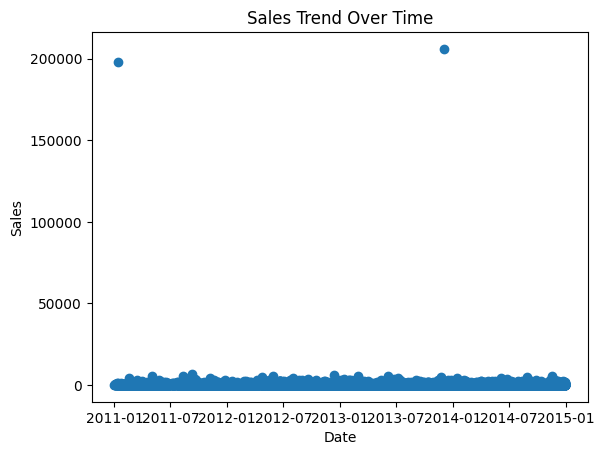

In [ ]:
plt.scatter(df['Date'], df['Sales'])
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Trend Over Time')
plt.show()

In [ ]:
# Observation:
# The scatter plot shows that most Sales values stay in the same
# lower range throughout the entire period. Although there are two
# very large outliers, the overall pattern does not rise over time.
#
# Conclusion:
# Sales do NOT generally increase over time. The dataset does not
# show an upward trend

In [ ]:
df.head()

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Date
381,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,Paper,"Xerox Memo Slips, Multicolor",0.0,0.0,0.0,1.0,2011-05-19
2156,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,Labels,"Hon Round Labels, Laser Printer Compatible",0.5,3.0,-1.0,1.0,2012-06-29
7091,BN-2014-5531507,9/15/14,Kayla Tearle,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Labels,"Hon Removable Labels, Adjustable",0.5,4.0,-3.0,1.0,2014-09-15
1179,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Binders,"Ibico Hole Reinforcements, Durable",0.5,4.0,-2.0,1.0,2011-11-16
3382,AZ-2013-273412,1/14/13,Zachary Warner,Austria,Vienna,Vienna,Central,Consumer,Immediate,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",0.0,4.0,0.0,1.0,2013-01-14


In [ ]:
# Calculate IQR for Sales
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

print("Q1 (25th percentile):", Q1)
print("Q3 (75th percentile):", Q3)
print("IQR:", IQR)

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1 (25th percentile): 48.0
Q3 (75th percentile): 314.0
IQR: 266.0
Lower Bound: -351.0
Upper Bound: 713.0


In [ ]:
# Identify outliers
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
outliers.head()

print("Number of outliers:", len(outliers))

Number of outliers: 873


In [ ]:
# Remove outliers using IQR method
df_cleaned = df[~((df['Sales'] < lower_bound) | (df['Sales'] > upper_bound))]

# Replace df with cleaned version
df = df_cleaned

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7163 entries, 381 to 464
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       7163 non-null   object        
 1   Order Date     7163 non-null   object        
 2   Customer Name  7162 non-null   object        
 3   Country        7162 non-null   object        
 4   State          7163 non-null   object        
 5   City           7159 non-null   object        
 6   Region         7163 non-null   object        
 7   Segment        7162 non-null   object        
 8   Ship Mode      7158 non-null   object        
 9   Category       7158 non-null   object        
 10  Sub-Category   7163 non-null   object        
 11  Product Name   7163 non-null   object        
 12  Discount       7157 non-null   float64       
 13  Sales          7163 non-null   float64       
 14  Profit         7152 non-null   float64       
 15  Quantity       7152 non-n

In [ ]:
df.head()

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Date
381,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,Paper,"Xerox Memo Slips, Multicolor",0.0,0.0,0.0,1.0,2011-05-19
2156,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,Labels,"Hon Round Labels, Laser Printer Compatible",0.5,3.0,-1.0,1.0,2012-06-29
7091,BN-2014-5531507,9/15/14,Kayla Tearle,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Labels,"Hon Removable Labels, Adjustable",0.5,4.0,-3.0,1.0,2014-09-15
1179,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Binders,"Ibico Hole Reinforcements, Durable",0.5,4.0,-2.0,1.0,2011-11-16
3382,AZ-2013-273412,1/14/13,Zachary Warner,Austria,Vienna,Vienna,Central,Consumer,Immediate,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",0.0,4.0,0.0,1.0,2013-01-14


In [ ]:
df['Year'] = df['Date'].dt.year

df.head()

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Date,Year
381,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,Paper,"Xerox Memo Slips, Multicolor",0.0,0.0,0.0,1.0,2011-05-19,2011
2156,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,Labels,"Hon Round Labels, Laser Printer Compatible",0.5,3.0,-1.0,1.0,2012-06-29,2012
7091,BN-2014-5531507,9/15/14,Kayla Tearle,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Labels,"Hon Removable Labels, Adjustable",0.5,4.0,-3.0,1.0,2014-09-15,2014
1179,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Binders,"Ibico Hole Reinforcements, Durable",0.5,4.0,-2.0,1.0,2011-11-16,2011
3382,AZ-2013-273412,1/14/13,Zachary Warner,Austria,Vienna,Vienna,Central,Consumer,Immediate,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",0.0,4.0,0.0,1.0,2013-01-14,2013


In [ ]:
# Top 3 States by Sales and Profit for each Year

# Group by Year and State and compute total Sales and Profit
state_year = df.groupby(['Year', 'State'])[['Sales', 'Profit']].sum()

In [ ]:
state_year_ind = df.groupby(['Year', 'State'])[['Sales', 'Profit']]


In [ ]:
state_year_ind.sum()

Sales  Profit
Year State                                            
2011 Abruzzi                              85.0   -33.0
     Alsace-Champagne-Ardenne-Lorraine  2035.0  -200.0
     Andalusía                          1468.0   385.0
     Antwerp                             674.0   159.0
     Apulia                             2888.0  -287.0
...                                        ...     ...
2014 Västra Götaland                    1312.0  -612.0
     Wales                              1430.0   370.0
     West Flanders                       291.0    34.0
     Zealand                             243.0  -245.0
     Zürich                             1842.0   338.0

[403 rows x 2 columns]

In [ ]:
state_year

Sales  Profit
Year State                                            
2011 Abruzzi                              85.0   -33.0
     Alsace-Champagne-Ardenne-Lorraine  2035.0  -200.0
     Andalusía                          1468.0   385.0
     Antwerp                             674.0   159.0
     Apulia                             2888.0  -287.0
...                                        ...     ...
2014 Västra Götaland                    1312.0  -612.0
     Wales                              1430.0   370.0
     West Flanders                       291.0    34.0
     Zealand                             243.0  -245.0
     Zürich                             1842.0   338.0

[403 rows x 2 columns]

In [ ]:
# Sort values within each Year (descending by Sales / Profit)
top_sales_sorted = state_year.sort_values(['Year', 'Sales'], ascending=[True, False])
top_profit_sorted = state_year.sort_values(['Year', 'Profit'], ascending=[True, False])

In [ ]:
# Select top 3 states for every year – by Sales
top3_sales = top_sales_sorted.groupby('Year').head(3)

In [ ]:
#  Select top 3 states for every year – by Profit
top3_profit = top_profit_sorted.groupby('Year').head(3)

In [ ]:
print("Top 3 States by Sales for each year:")
top3_sales

print("Top 3 States by Profit for each year:")
top3_profit

Top 3 States by Sales for each year:
Top 3 States by Profit for each year:


Sales  Profit
Year State                                  
2011 England                 28213.0  5829.0
     North Rhine-Westphalia  19955.0  4068.0
     Ile-de-France           18056.0  3213.0
2012 England                 35886.0  6562.0
     North Rhine-Westphalia  21350.0  4310.0
     Ile-de-France           23897.0  4105.0
2013 England                 44218.0  7540.0
     Ile-de-France           24374.0  4242.0
     North Rhine-Westphalia  17532.0  3666.0
2014 England                 51984.0  8327.0
     Ile-de-France           32180.0  5250.0
     North Rhine-Westphalia  22742.0  4201.0

In [ ]:
top3_sales


Sales  Profit
Year State                                  
2011 England                 28213.0  5829.0
     North Rhine-Westphalia  19955.0  4068.0
     Ile-de-France           18056.0  3213.0
2012 England                 35886.0  6562.0
     Ile-de-France           23897.0  4105.0
     North Rhine-Westphalia  21350.0  4310.0
2013 England                 44218.0  7540.0
     Ile-de-France           24374.0  4242.0
     North Rhine-Westphalia  17532.0  3666.0
2014 England                 51984.0  8327.0
     Ile-de-France           32180.0  5250.0
     North Rhine-Westphalia  22742.0  4201.0

In [ ]:
# Step 2.5 – Part 2
# Does giving discounts increase Sales and/or Profit?

discount_summary = df.groupby('Discount')[['Sales', 'Profit']].sum()

discount_summary

,Sales,Profit
Discount,,
0.0,632463.0,154751.0
0.1,238549.0,39309.0
0.2,96779.0,7653.0
0.3,4846.0,-612.0
0.4,45732.0,-12030.0
0.5,104244.0,-53171.0
0.6,10563.0,-8986.0
0.7,4974.0,-6032.0
0.8,139.0,-426.0


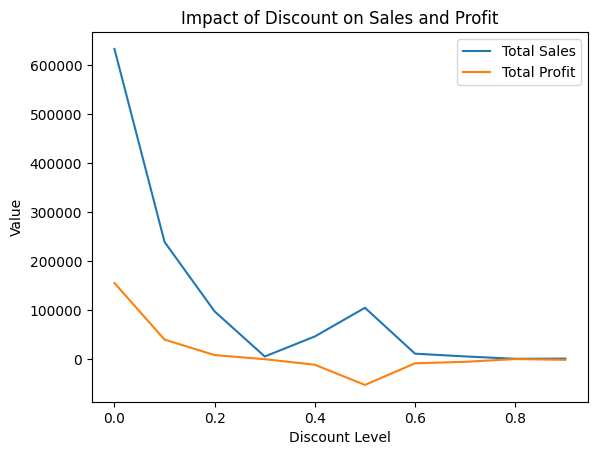

In [ ]:
# Plot total Sales and Profit against Discount levels
plt.plot(discount_summary.index, discount_summary['Sales'], label='Total Sales')
plt.plot(discount_summary.index, discount_summary['Profit'], label='Total Profit')

plt.xlabel('Discount Level')
plt.ylabel('Value')
plt.title('Impact of Discount on Sales and Profit')
plt.legend()
plt.show()



# Interpretation of Discount vs Sales and Profit
#
# 1. Sales and profit are highest at 0% discount.
#
# 2. As the discount increases, both Sales and Profit generally
#    decline. Sales rise slightly around the 40–50% discount
#    range, but profit becomes strongly negative.
#
# 3. At the 80% discount level, both Sales and Profit drop
#    to almost zero. This indicates heavy losses — the items are
#    essentially being sold below cost.
#
# 4. The optimal discount level for maximizing profit is 0%.
#    Higher discounts do not improve profit in any year, and the
#    overall pattern remains the same across all years.


In [ ]:
# For regression, I took the help of AI
import pandas as pd
import numpy as np

import statsmodels.api as sm

# Keep the columns we want (simple and common)
df_reg = df[['Sales', 'Discount', 'Profit', 'Quantity', 'Segment', 'Ship Mode', 'Category', 'Region']]

# Drop rows with missing values in these columns
df_reg = df_reg.dropna()

df_reg.head()

,Sales,Discount,Profit,Quantity,Segment,Ship Mode,Category,Region
381,0.0,0.0,0.0,1.0,Corporate,Economy,Office Supplies,South
2156,3.0,0.5,-1.0,1.0,Consumer,Economy,Office Supplies,North
7091,4.0,0.5,-3.0,1.0,Corporate,Economy,Office Supplies,North
1179,4.0,0.5,-2.0,1.0,Corporate,Economy,Office Supplies,North
3382,4.0,0.0,0.0,1.0,Consumer,Immediate,Office Supplies,Central


In [ ]:
# Convert categorical columns to dummy variables
df_reg_dum = pd.get_dummies(df_reg, columns=['Segment', 'Ship Mode', 'Category', 'Region'], drop_first=True)

df_reg_dum.head()

,Sales,Discount,Profit,Quantity,Segment_Corporate,Segment_Home Office,Ship Mode_Economy Plus,Ship Mode_Immediate,Ship Mode_Priority,Category_Office Supplies,Category_Technology,Region_North,Region_South
381,0.0,0.0,0.0,1.0,True,False,False,False,False,True,False,False,True
2156,3.0,0.5,-1.0,1.0,False,False,False,False,False,True,False,True,False
7091,4.0,0.5,-3.0,1.0,True,False,False,False,False,True,False,True,False
1179,4.0,0.5,-2.0,1.0,True,False,False,False,False,True,False,True,False
3382,4.0,0.0,0.0,1.0,False,False,False,True,False,True,False,False,False


In [ ]:
# Convert categorical columns to dummy variables
df_reg_dum = pd.get_dummies(df_reg, columns=['Segment', 'Ship Mode', 'Category', 'Region'], drop_first=True)

# Convert boolean columns to integers (0s and 1s)
bool_cols = df_reg_dum.select_dtypes(include='bool').columns
df_reg_dum[bool_cols] = df_reg_dum[bool_cols].astype(int)

# Define target and predictors
y = df_reg_dum['Sales']
X = df_reg_dum.drop(columns=['Sales'])

# Add constant for intercept
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     385.7
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:01:50   Log-Likelihood:                -44536.
No. Observations:                7141   AIC:                         8.910e+04
Df Residuals:                    7128   BIC:                         8.919e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                      157.6121      5.447     28.934      0.000     146.934     168.290
Discount                    20.1200      9.508      2.116      0.034       1.481      38.759
Profit                       0.4333      0.023     18.439      0.000       0.387       0.479
Quantity                    25.1462      0.706     35.633      0.000      23.763      26.530
Segment_Corporate           -1.7057      3.325     -0.513      0.608      -8.224       4.813
Segment_Home Office          3.7612      4.093      0.919      0.358      -4.261      11.784
Ship Mode_Economy Plus      -0.1393      3.809     -0.037      0.971      -7.606       7.327
Ship Mode_Immediate          2.6806      6.685      0.401      0.688     -10.425      15.786
Ship Mode_Priority           2.4541      4.273      0.574      0.566      -5.923      10.831
Category_Office Supplies  -147.1636      4.467    -32.944      0.000    -155.920    -138.407
Category_Technology         53.7300      5.484      9.798      0.000      42.981      64.479
Region_North                -9.7389      3.712     -2.624      0.009     -17.016      -2.462
Region_South                -0.0506      3.666     -0.014      0.989      -7.237       7.136
==============================================================================
Omnibus:                     2316.082   Durbin-Watson:                   0.700
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8484.970
Skew:                           1.602   Prob(JB):                         0.00
Kurtosis:                       7.272   Cond. No.                         508.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Based on the regression output (using a 5 percent significance level),
# the factors that affect Sales the most [meaning they are statistically significant with p < 0.05] are
# Discount (p = 0.034), Profit (p = 0.000), Quantity (p = 0.000), Category: Technology (p = 0.000), and
# Region: North (p = 0.009). All other factors shown [Segment dummies, Ship Mode dummies, Category:
# Office Supplies, and Region: South] have p-values
# greater than 0.05, so they are not significant predictors of Sales in this model.

# If we look at the direction and size of the coefficients,
# Sales increases with Quantity and Profit, and being in Technology category is
# associated with higher Sales compared to the baseline category.
# Discount is also positively associated with
# Sales [but the evidence is weaker compared to the others since its p-value is closer to 0.05].
# Region North has a negative coefficient, meaning Sales tend to be lower there compared to the
# baseline region after controlling for other variables.

In [ ]:
df.head()

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Date,Year
381,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,Paper,"Xerox Memo Slips, Multicolor",0.0,0.0,0.0,1.0,2011-05-19,2011
2156,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,Labels,"Hon Round Labels, Laser Printer Compatible",0.5,3.0,-1.0,1.0,2012-06-29,2012
7091,BN-2014-5531507,9/15/14,Kayla Tearle,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Labels,"Hon Removable Labels, Adjustable",0.5,4.0,-3.0,1.0,2014-09-15,2014
1179,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Binders,"Ibico Hole Reinforcements, Durable",0.5,4.0,-2.0,1.0,2011-11-16,2011
3382,AZ-2013-273412,1/14/13,Zachary Warner,Austria,Vienna,Vienna,Central,Consumer,Immediate,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",0.0,4.0,0.0,1.0,2013-01-14,2013


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7163 entries, 381 to 464
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       7163 non-null   object        
 1   Order Date     7163 non-null   object        
 2   Customer Name  7162 non-null   object        
 3   Country        7162 non-null   object        
 4   State          7163 non-null   object        
 5   City           7159 non-null   object        
 6   Region         7163 non-null   object        
 7   Segment        7162 non-null   object        
 8   Ship Mode      7158 non-null   object        
 9   Category       7158 non-null   object        
 10  Sub-Category   7163 non-null   object        
 11  Product Name   7163 non-null   object        
 12  Discount       7157 non-null   float64       
 13  Sales          7163 non-null   float64       
 14  Profit         7152 non-null   float64       
 15  Quantity       7152 non-n

In [ ]:
df['Date'].min()

Timestamp('2011-01-01 00:00:00')

In [ ]:
df.groupby('Customer Name')['Year'].min()

,Year
Customer Name,
Aaron Bootman,2011
Aaron Cunningham,2011
Aaron Davey,2011
Aaron Macrossan,2011
Abbie Perry,2011
...,...
Zara Loton,2013
Zara Money,2011
Zoe Lanigan,2011


In [ ]:
df.groupby('Customer Name')['Year'].max()


,Year
Customer Name,
Aaron Bootman,2014
Aaron Cunningham,2014
Aaron Davey,2013
Aaron Macrossan,2011
Abbie Perry,2014
...,...
Zara Loton,2014
Zara Money,2014
Zoe Lanigan,2014


In [ ]:
# Identifying first year customer made a transaction
dfEarlyOrder = df.groupby('Customer Name')['Year'].min()
dfEarlyOrder

,Year
Customer Name,
Aaron Bootman,2011
Aaron Cunningham,2011
Aaron Davey,2011
Aaron Macrossan,2011
Abbie Perry,2011
...,...
Zara Loton,2013
Zara Money,2011
Zoe Lanigan,2011


In [ ]:
# Reset index for cleaner table
dfEarlyOrder = dfEarlyOrder.reset_index()
dfEarlyOrder


# This shows I have 792 different customers

,Customer Name,Year
0,Aaron Bootman,2011
1,Aaron Cunningham,2011
2,Aaron Davey,2011
3,Aaron Macrossan,2011
4,Abbie Perry,2011
...,...,...
787,Zara Loton,2013
788,Zara Money,2011
789,Zoe Lanigan,2011
790,Zoe Lowin,2011


In [ ]:
# Merge main df with earliest transaction year per customer
pd.merge(df, dfEarlyOrder, on='Customer Name', how='left')

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Date,Year_x,Year_y
0,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,Paper,"Xerox Memo Slips, Multicolor",0.0,0.0,0.0,1.0,2011-05-19,2011,2011.0
1,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,Labels,"Hon Round Labels, Laser Printer Compatible",0.5,3.0,-1.0,1.0,2012-06-29,2012,2012.0
2,BN-2014-5531507,9/15/14,Kayla Tearle,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Labels,"Hon Removable Labels, Adjustable",0.5,4.0,-3.0,1.0,2014-09-15,2014,2011.0
3,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Binders,"Ibico Hole Reinforcements, Durable",0.5,4.0,-2.0,1.0,2011-11-16,2011,2011.0
4,AZ-2013-273412,1/14/13,Zachary Warner,Austria,Vienna,Vienna,Central,Consumer,Immediate,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",0.0,4.0,0.0,1.0,2013-01-14,2013,2011.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,BN-2014-8834829,11/18/14,Piper Wilder-Neligan,France,Ile-de-France,Pantin,Central,Consumer,Economy Plus,Office Supplies,Storage,"Smead Lockers, Wire Frame",0.1,711.0,-8.0,4.0,2014-11-18,2014,2011.0
7159,AZ-2012-1418024,7/1/12,Tricia Bustamante,United Kingdom,Scotland,Edinburgh,North,Corporate,Economy,Furniture,Bookcases,"Ikea 3-Shelf Cabinet, Traditional",0.0,712.0,320.0,5.0,2012-07-01,2012,2012.0
7160,AZ-2012-1125061,9/18/12,Jeremy Pilcher,Germany,North Rhine-Westphalia,Dortmund,Central,Corporate,Economy,Furniture,Bookcases,"Safco Floating Shelf Set, Pine",0.1,713.0,40.0,4.0,2012-09-18,2012,2011.0
7161,AZ-2011-2598415,5/27/11,Lincoln Want,Germany,North Rhine-Westphalia,Pulheim,Central,Consumer,Priority,Furniture,Bookcases,"Safco Floating Shelf Set, Pine",0.1,713.0,40.0,4.0,2011-05-27,2011,2011.0


In [ ]:
df_final = pd.merge(df, dfEarlyOrder, on='Customer Name', how='left')
df_final

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Date,Year_x,Year_y
0,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,Paper,"Xerox Memo Slips, Multicolor",0.0,0.0,0.0,1.0,2011-05-19,2011,2011.0
1,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,Labels,"Hon Round Labels, Laser Printer Compatible",0.5,3.0,-1.0,1.0,2012-06-29,2012,2012.0
2,BN-2014-5531507,9/15/14,Kayla Tearle,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Labels,"Hon Removable Labels, Adjustable",0.5,4.0,-3.0,1.0,2014-09-15,2014,2011.0
3,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Binders,"Ibico Hole Reinforcements, Durable",0.5,4.0,-2.0,1.0,2011-11-16,2011,2011.0
4,AZ-2013-273412,1/14/13,Zachary Warner,Austria,Vienna,Vienna,Central,Consumer,Immediate,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",0.0,4.0,0.0,1.0,2013-01-14,2013,2011.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,BN-2014-8834829,11/18/14,Piper Wilder-Neligan,France,Ile-de-France,Pantin,Central,Consumer,Economy Plus,Office Supplies,Storage,"Smead Lockers, Wire Frame",0.1,711.0,-8.0,4.0,2014-11-18,2014,2011.0
7159,AZ-2012-1418024,7/1/12,Tricia Bustamante,United Kingdom,Scotland,Edinburgh,North,Corporate,Economy,Furniture,Bookcases,"Ikea 3-Shelf Cabinet, Traditional",0.0,712.0,320.0,5.0,2012-07-01,2012,2012.0
7160,AZ-2012-1125061,9/18/12,Jeremy Pilcher,Germany,North Rhine-Westphalia,Dortmund,Central,Corporate,Economy,Furniture,Bookcases,"Safco Floating Shelf Set, Pine",0.1,713.0,40.0,4.0,2012-09-18,2012,2011.0
7161,AZ-2011-2598415,5/27/11,Lincoln Want,Germany,North Rhine-Westphalia,Pulheim,Central,Consumer,Priority,Furniture,Bookcases,"Safco Floating Shelf Set, Pine",0.1,713.0,40.0,4.0,2011-05-27,2011,2011.0


In [ ]:
df_final.head()

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Date,Year_x,Year_y
0,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,Paper,"Xerox Memo Slips, Multicolor",0.0,0.0,0.0,1.0,2011-05-19,2011,2011.0
1,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,Labels,"Hon Round Labels, Laser Printer Compatible",0.5,3.0,-1.0,1.0,2012-06-29,2012,2012.0
2,BN-2014-5531507,9/15/14,Kayla Tearle,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Labels,"Hon Removable Labels, Adjustable",0.5,4.0,-3.0,1.0,2014-09-15,2014,2011.0
3,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Binders,"Ibico Hole Reinforcements, Durable",0.5,4.0,-2.0,1.0,2011-11-16,2011,2011.0
4,AZ-2013-273412,1/14/13,Zachary Warner,Austria,Vienna,Vienna,Central,Consumer,Immediate,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",0.0,4.0,0.0,1.0,2013-01-14,2013,2011.0


In [ ]:
# Rename earliest year column
df_final = df_final.rename(columns={'Year_y': 'OriginYear'})
df_final

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Date,Year_x,OriginYear
0,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,Paper,"Xerox Memo Slips, Multicolor",0.0,0.0,0.0,1.0,2011-05-19,2011,2011.0
1,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,Labels,"Hon Round Labels, Laser Printer Compatible",0.5,3.0,-1.0,1.0,2012-06-29,2012,2012.0
2,BN-2014-5531507,9/15/14,Kayla Tearle,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Labels,"Hon Removable Labels, Adjustable",0.5,4.0,-3.0,1.0,2014-09-15,2014,2011.0
3,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,Binders,"Ibico Hole Reinforcements, Durable",0.5,4.0,-2.0,1.0,2011-11-16,2011,2011.0
4,AZ-2013-273412,1/14/13,Zachary Warner,Austria,Vienna,Vienna,Central,Consumer,Immediate,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",0.0,4.0,0.0,1.0,2013-01-14,2013,2011.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,BN-2014-8834829,11/18/14,Piper Wilder-Neligan,France,Ile-de-France,Pantin,Central,Consumer,Economy Plus,Office Supplies,Storage,"Smead Lockers, Wire Frame",0.1,711.0,-8.0,4.0,2014-11-18,2014,2011.0
7159,AZ-2012-1418024,7/1/12,Tricia Bustamante,United Kingdom,Scotland,Edinburgh,North,Corporate,Economy,Furniture,Bookcases,"Ikea 3-Shelf Cabinet, Traditional",0.0,712.0,320.0,5.0,2012-07-01,2012,2012.0
7160,AZ-2012-1125061,9/18/12,Jeremy Pilcher,Germany,North Rhine-Westphalia,Dortmund,Central,Corporate,Economy,Furniture,Bookcases,"Safco Floating Shelf Set, Pine",0.1,713.0,40.0,4.0,2012-09-18,2012,2011.0
7161,AZ-2011-2598415,5/27/11,Lincoln Want,Germany,North Rhine-Westphalia,Pulheim,Central,Consumer,Priority,Furniture,Bookcases,"Safco Floating Shelf Set, Pine",0.1,713.0,40.0,4.0,2011-05-27,2011,2011.0


In [ ]:

df_final[['Customer Name', 'Year_x', 'OriginYear', 'Date']].head(10)

,Customer Name,Year_x,OriginYear,Date
0,Milla Hollinworth,2011,2011.0,2011-05-19
1,Kristen Holland,2012,2012.0,2012-06-29
2,Kayla Tearle,2014,2011.0,2014-09-15
3,Claudia Poore,2011,2011.0,2011-11-16
4,Zachary Warner,2013,2011.0,2013-01-14
5,Ashton Charles,2013,2011.0,2013-11-28
6,Isabella Fowler,2013,2012.0,2013-06-23
7,Alexandra Portus,2014,2011.0,2014-08-11
8,Daniel Burke,2011,2011.0,2011-10-08
9,Alexander Bond,2014,2011.0,2014-02-27


In [ ]:
# STEP 3:
# - OriginYear is defined as the earliest year in which a customer appears in the dataset.
# - I calculated this by grouping transactions by Customer Name and taking the minimum Year.
# - Then I merged this value back into the full dataset so each transaction row has:
#   (1) Year_x = transaction year
#   (2) OriginYear = customer acquisition year

In [ ]:
# Calculate Age in months since OriginYear
df_final['Age'] = (df_final['Date'] -
                   pd.to_datetime(df_final['OriginYear'], format='%Y')).dt.days / 31

# Define Age Range function
def ageRangeFunc(d):
    if (d['Age'] <= 12):
        return 12
    elif (d['Age'] > 12 and d['Age'] <= 24):
        return 24
    elif (d['Age'] > 24 and d['Age'] <= 36):
        return 36
    elif (d['Age'] > 36 and d['Age'] <= 48):
        return 48
    elif (d['Age'] > 48 and d['Age'] <= 60):
        return 60
    else:
        return 72

In [ ]:
# Apply and create new column
df_final['AgeRange'] = df_final.apply(ageRangeFunc, axis=1)

In [ ]:
df_final[['Customer Name','OriginYear','Year_x','Date','Age','AgeRange','Sales']].head()

,Customer Name,OriginYear,Year_x,Date,Age,AgeRange,Sales
0,Milla Hollinworth,2011.0,2011,2011-05-19,4.451613,12,0.0
1,Kristen Holland,2012.0,2012,2012-06-29,5.806452,12,3.0
2,Kayla Tearle,2011.0,2014,2014-09-15,43.645161,48,4.0
3,Claudia Poore,2011.0,2011,2011-11-16,10.290323,12,4.0
4,Zachary Warner,2011.0,2013,2013-01-14,24.000000,24,4.0


In [ ]:
# Removing negative Sales
df_final = df_final[df_final['Sales'] >= 0]

In [ ]:
df_final

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,...,Product Name,Discount,Sales,Profit,Quantity,Date,Year_x,OriginYear,Age,AgeRange
0,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,...,"Xerox Memo Slips, Multicolor",0.0,0.0,0.0,1.0,2011-05-19,2011,2011.0,4.451613,12
1,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,...,"Hon Round Labels, Laser Printer Compatible",0.5,3.0,-1.0,1.0,2012-06-29,2012,2012.0,5.806452,12
2,BN-2014-5531507,9/15/14,Kayla Tearle,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,...,"Hon Removable Labels, Adjustable",0.5,4.0,-3.0,1.0,2014-09-15,2014,2011.0,43.645161,48
3,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,...,"Ibico Hole Reinforcements, Durable",0.5,4.0,-2.0,1.0,2011-11-16,2011,2011.0,10.290323,12
4,AZ-2013-273412,1/14/13,Zachary Warner,Austria,Vienna,Vienna,Central,Consumer,Immediate,Office Supplies,...,"Wilson Jones Hole Reinforcements, Clear",0.0,4.0,0.0,1.0,2013-01-14,2013,2011.0,24.000000,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,BN-2014-8834829,11/18/14,Piper Wilder-Neligan,France,Ile-de-France,Pantin,Central,Consumer,Economy Plus,Office Supplies,...,"Smead Lockers, Wire Frame",0.1,711.0,-8.0,4.0,2014-11-18,2014,2011.0,45.709677,48
7159,AZ-2012-1418024,7/1/12,Tricia Bustamante,United Kingdom,Scotland,Edinburgh,North,Corporate,Economy,Furniture,...,"Ikea 3-Shelf Cabinet, Traditional",0.0,712.0,320.0,5.0,2012-07-01,2012,2012.0,5.870968,12
7160,AZ-2012-1125061,9/18/12,Jeremy Pilcher,Germany,North Rhine-Westphalia,Dortmund,Central,Corporate,Economy,Furniture,...,"Safco Floating Shelf Set, Pine",0.1,713.0,40.0,4.0,2012-09-18,2012,2011.0,20.193548,24
7161,AZ-2011-2598415,5/27/11,Lincoln Want,Germany,North Rhine-Westphalia,Pulheim,Central,Consumer,Priority,Furniture,...,"Safco Floating Shelf Set, Pine",0.1,713.0,40.0,4.0,2011-05-27,2011,2011.0,4.709677,12


In [ ]:
# Check missing OriginYear
df_final['OriginYear'].isnull().sum()

np.int64(1)

In [ ]:
df_final[df_final['OriginYear'].isnull()][['Customer Name', 'Year_x', 'Date']].head(10)

,Customer Name,Year_x,Date
1191,NaN,2011,2011-06-21


In [ ]:
# Remove rows with missing OriginYear (cannot assign cohort)
df_final = df_final.dropna(subset=['OriginYear'])

In [ ]:
# I wanted to create a table like the table shown in word file so I took the help of AI for this format

df_final.loc[:, 'Origin'] = df_final['OriginYear'].astype(int).astype(str) + '-01-01 - ' + df_final['OriginYear'].astype(int).astype(str) + '-12-31'

In [ ]:
df_final[['OriginYear','Origin']].head()

,OriginYear,Origin
0,2011.0,2011-01-01 - 2011-12-31
1,2012.0,2012-01-01 - 2012-12-31
2,2011.0,2011-01-01 - 2011-12-31
3,2011.0,2011-01-01 - 2011-12-31
4,2011.0,2011-01-01 - 2011-12-31


In [ ]:
df_final[['OriginYear','AgeRange','Sales']].head()

,OriginYear,AgeRange,Sales
0,2011.0,12,0.0
1,2012.0,12,3.0
2,2011.0,48,4.0
3,2011.0,12,4.0
4,2011.0,24,4.0


In [ ]:
trans_amount = df_final.pivot_table(values='Sales',
                                    index='OriginYear',
                                    columns='AgeRange',
                                    aggfunc='sum')
trans_amount

AgeRange,12,24,36,48
OriginYear,,,,
2011.0,211952.0,162737.0,171980.0,221503.0
2012.0,99875.0,85747.0,92326.0,NaN
2013.0,45311.0,39489.0,NaN,NaN
2014.0,8454.0,NaN,NaN,NaN


In [ ]:
trans_amount = trans_amount.cumsum(axis=1)   # axis = 1 to cumsum over columns
trans_amount

AgeRange,12,24,36,48
OriginYear,,,,
2011.0,211952.0,374689.0,546669.0,768172.0
2012.0,99875.0,185622.0,277948.0,NaN
2013.0,45311.0,84800.0,NaN,NaN
2014.0,8454.0,NaN,NaN,NaN


In [ ]:

# Create Origin label
df_final.loc[:, 'Origin'] = df_final['OriginYear'].astype(int).astype(str) + '-01-01 - ' + df_final['OriginYear'].astype(int).astype(str) + '-12-31'



In [ ]:
# Add Origin label into the table
trans_amount = trans_amount.reset_index()
trans_amount['Origin'] = trans_amount['OriginYear'].astype(int).astype(str) + '-01-01 - ' + trans_amount['OriginYear'].astype(int).astype(str) + '-12-31'



In [ ]:
# Set Origin as index
trans_amount = trans_amount.set_index('Origin')



In [ ]:

trans_amount

AgeRange,OriginYear,12,24,36,48
Origin,,,,,
2011-01-01 - 2011-12-31,2011.0,211952.0,374689.0,546669.0,768172.0
2012-01-01 - 2012-12-31,2012.0,99875.0,185622.0,277948.0,NaN
2013-01-01 - 2013-12-31,2013.0,45311.0,84800.0,NaN,NaN
2014-01-01 - 2014-12-31,2014.0,8454.0,NaN,NaN,NaN


In [ ]:
df_final["Year_x"].max()

2014

In [ ]:
df_final['AgeRange'].value_counts().sort_index()

,count
AgeRange,
12,2303
24,1825
36,1693
48,1341


In [ ]:
df_new = df_final[df_final['Year_x'] == df_final['OriginYear']]
df_new

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,...,Discount,Sales,Profit,Quantity,Date,Year_x,OriginYear,Age,AgeRange,Origin
0,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,...,0.0,0.0,0.0,1.0,2011-05-19,2011,2011.0,4.451613,12,2011-01-01 - 2011-12-31
1,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,...,0.5,3.0,-1.0,1.0,2012-06-29,2012,2012.0,5.806452,12,2012-01-01 - 2012-12-31
3,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,...,0.5,4.0,-2.0,1.0,2011-11-16,2011,2011.0,10.290323,12,2011-01-01 - 2011-12-31
8,BN-2011-1778575,10/8/11,Daniel Burke,Sweden,Stockholm,Stockholm,North,Home Office,Economy Plus,Office Supplies,...,0.5,5.0,0.0,2.0,2011-10-08,2011,2011.0,9.032258,12,2011-01-01 - 2011-12-31
10,AZ-2012-7448408,7/14/12,Jacob Varley,United Kingdom,England,Sheffield,North,Corporate,Economy,Office Supplies,...,0.5,5.0,-5.0,1.0,2012-07-14,2012,2012.0,6.290323,12,2012-01-01 - 2012-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7153,AZ-2011-8949674,12/20/11,Kerry Dorsey,France,Aquitaine-Limousin-Poitou-Charentes,Bayonne,Central,Consumer,Economy Plus,Furniture,...,0.1,705.0,102.0,4.0,2011-12-20,2011,2011.0,11.387097,12,2011-01-01 - 2011-12-31
7157,AZ-2012-334946,12/18/12,John Harris,Spain,Murcia,Murcia,South,Corporate,Economy Plus,Office Supplies,...,0.1,711.0,-8.0,4.0,2012-12-18,2012,2012.0,11.354839,12,2012-01-01 - 2012-12-31
7159,AZ-2012-1418024,7/1/12,Tricia Bustamante,United Kingdom,Scotland,Edinburgh,North,Corporate,Economy,Furniture,...,0.0,712.0,320.0,5.0,2012-07-01,2012,2012.0,5.870968,12,2012-01-01 - 2012-12-31
7161,AZ-2011-2598415,5/27/11,Lincoln Want,Germany,North Rhine-Westphalia,Pulheim,Central,Consumer,Priority,Furniture,...,0.1,713.0,40.0,4.0,2011-05-27,2011,2011.0,4.709677,12,2011-01-01 - 2011-12-31


In [ ]:
# A new customer may have multiple purchases in their origin year
df_new.duplicated(subset=['Customer Name']).value_counts()

# Keep only the first appearance of each customer
df_new = df_new.drop_duplicates(subset=['Customer Name'])
df_new

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,...,Discount,Sales,Profit,Quantity,Date,Year_x,OriginYear,Age,AgeRange,Origin
0,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,...,0.0,0.0,0.0,1.0,2011-05-19,2011,2011.0,4.451613,12,2011-01-01 - 2011-12-31
1,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,...,0.5,3.0,-1.0,1.0,2012-06-29,2012,2012.0,5.806452,12,2012-01-01 - 2012-12-31
3,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,...,0.5,4.0,-2.0,1.0,2011-11-16,2011,2011.0,10.290323,12,2011-01-01 - 2011-12-31
8,BN-2011-1778575,10/8/11,Daniel Burke,Sweden,Stockholm,Stockholm,North,Home Office,Economy Plus,Office Supplies,...,0.5,5.0,0.0,2.0,2011-10-08,2011,2011.0,9.032258,12,2011-01-01 - 2011-12-31
10,AZ-2012-7448408,7/14/12,Jacob Varley,United Kingdom,England,Sheffield,North,Corporate,Economy,Office Supplies,...,0.5,5.0,-5.0,1.0,2012-07-14,2012,2012.0,6.290323,12,2012-01-01 - 2012-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,BN-2011-7737747,5/12/11,Patrick Townson,France,Aquitaine-Limousin-Poitou-Charentes,Bordeaux,Central,Home Office,Priority,Furniture,...,0.4,627.0,-135.0,2.0,2011-05-12,2011,2011.0,4.225806,12,2011-01-01 - 2011-12-31
7028,AZ-2011-5827692,6/28/11,Jonathan Bottrill,United Kingdom,Scotland,Glasgow,North,Consumer,Economy,Technology,...,0.0,628.0,6.0,2.0,2011-06-28,2011,2011.0,5.741935,12,2011-01-01 - 2011-12-31
7058,AZ-2011-7873401,8/18/11,Claire Harrington,Germany,North Rhine-Westphalia,Cologne,Central,Home Office,Economy Plus,Technology,...,0.0,640.0,160.0,2.0,2011-08-18,2011,2011.0,7.387097,12,2011-01-01 - 2011-12-31
7103,BN-2011-8607391,6/9/11,William Reichert,France,Nord-Pas-de-Calais-Picardie,Hautmont,Central,Consumer,Priority,Technology,...,0.2,668.0,-31.0,3.0,2011-06-09,2011,2011.0,5.129032,12,2011-01-01 - 2011-12-31


In [ ]:
# Count new customers per origin year
new_cust = df_new.groupby('OriginYear')['Customer Name'].nunique()
new_cust

,Customer Name
OriginYear,
2011.0,475
2012.0,206
2013.0,91
2014.0,20


In [ ]:
# Convert to DataFrame
NewCustomers_table = new_cust.reset_index()
NewCustomers_table.columns = ['OriginYear', 'NewCust']

In [ ]:
# Create Origin label like example
NewCustomers_table['Origin'] = NewCustomers_table['OriginYear'].astype(int).astype(str) + '-01-01 - ' + NewCustomers_table['OriginYear'].astype(int).astype(str) + '-12-31'


In [ ]:
# Create columns 12,24,36,48,60,72 (same value repeated)
NewCustomers_table[12] = NewCustomers_table['NewCust']
NewCustomers_table[24] = NewCustomers_table['NewCust']
NewCustomers_table[36] = NewCustomers_table['NewCust']
NewCustomers_table[48] = NewCustomers_table['NewCust']
NewCustomers_table[60] = NewCustomers_table['NewCust']
NewCustomers_table[72] = NewCustomers_table['NewCust']

In [ ]:
# Keep only required columns and set index
NewCustomers_table = NewCustomers_table[['Origin', 12, 24, 36, 48, 60, 72]]
NewCustomers_table = NewCustomers_table.set_index('Origin')

In [ ]:
NewCustomers_table

,12,24,36,48,60,72
Origin,,,,,,
2011-01-01 - 2011-12-31,475,475,475,475,475,475
2012-01-01 - 2012-12-31,206,206,206,206,206,206
2013-01-01 - 2013-12-31,91,91,91,91,91,91
2014-01-01 - 2014-12-31,20,20,20,20,20,20


In [ ]:
trans_amount.columns


Index([12, 24, 36, 48], dtype='object', name='AgeRange')

In [ ]:
NewCustomers_table.columns

Index([12, 24, 36, 48, 60, 72], dtype='object')

In [ ]:
# Both had different columns so to make them same
if 'OriginYear' in trans_amount.columns:
    trans_amount = trans_amount.drop(columns=['OriginYear'])

trans_amount.columns

Index([12, 24, 36, 48], dtype='object', name='AgeRange')

In [ ]:
NewCustomers_table.columns

Index([12, 24, 36, 48, 60, 72], dtype='object')

In [ ]:
# To keep only common age brackets
common_cols = trans_amount.columns.intersection(NewCustomers_table.columns)

trans_amount = trans_amount[common_cols]
NewCustomers_table = NewCustomers_table[common_cols]

trans_amount.columns, NewCustomers_table.columns

(Index([12, 24, 36, 48], dtype='object', name='AgeRange'),
 Index([12, 24, 36, 48], dtype='object'))

In [ ]:
HistoricCLV_table = trans_amount / NewCustomers_table
HistoricCLV_table.round(2)

AgeRange,12,24,36,48
Origin,,,,
2011-01-01 - 2011-12-31,446.21,788.82,1150.88,1617.2
2012-01-01 - 2012-12-31,484.83,901.08,1349.26,NaN
2013-01-01 - 2013-12-31,497.92,931.87,NaN,NaN
2014-01-01 - 2014-12-31,422.70,NaN,NaN,NaN


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_new.head()

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,...,Discount,Sales,Profit,Quantity,Date,Year_x,OriginYear,Age,AgeRange,Origin
0,AZ-2011-309750,5/19/11,Milla Hollinworth,Spain,Castile-La Mancha,Toledo,South,Corporate,Economy,Office Supplies,...,0.0,0.0,0.0,1.0,2011-05-19,2011,2011.0,4.451613,12,2011-01-01 - 2011-12-31
1,BN-2012-8400051,6/29/12,Kristen Holland,Sweden,Stockholm,Solna,North,Consumer,Economy,Office Supplies,...,0.5,3.0,-1.0,1.0,2012-06-29,2012,2012.0,5.806452,12,2012-01-01 - 2012-12-31
3,BN-2011-5491702,11/16/11,Claudia Poore,Sweden,Stockholm,Stockholm,North,Corporate,Economy,Office Supplies,...,0.5,4.0,-2.0,1.0,2011-11-16,2011,2011.0,10.290323,12,2011-01-01 - 2011-12-31
8,BN-2011-1778575,10/8/11,Daniel Burke,Sweden,Stockholm,Stockholm,North,Home Office,Economy Plus,Office Supplies,...,0.5,5.0,0.0,2.0,2011-10-08,2011,2011.0,9.032258,12,2011-01-01 - 2011-12-31
10,AZ-2012-7448408,7/14/12,Jacob Varley,United Kingdom,England,Sheffield,North,Corporate,Economy,Office Supplies,...,0.5,5.0,-5.0,1.0,2012-07-14,2012,2012.0,6.290323,12,2012-01-01 - 2012-12-31


In [ ]:
print('df_final exists:', 'df_final' in globals())
print('trans_amount exists:', 'trans_amount' in globals())

df_final exists: True
trans_amount exists: True


In [ ]:
trans_amount.head()

AgeRange,12,24,36,48
Origin,,,,
2011-01-01 - 2011-12-31,211952.0,374689.0,546669.0,768172.0
2012-01-01 - 2012-12-31,99875.0,185622.0,277948.0,NaN
2013-01-01 - 2013-12-31,45311.0,84800.0,NaN,NaN
2014-01-01 - 2014-12-31,8454.0,NaN,NaN,NaN


In [ ]:
unpivot_trans = trans_amount.reset_index().melt(id_vars=['Origin'],
                                                var_name='Age',
                                                value_name='Value')
unpivot_trans.head()

,Origin,Age,Value
0,2011-01-01 - 2011-12-31,12,211952.0
1,2012-01-01 - 2012-12-31,12,99875.0
2,2013-01-01 - 2013-12-31,12,45311.0
3,2014-01-01 - 2014-12-31,12,8454.0
4,2011-01-01 - 2011-12-31,24,374689.0


In [ ]:
trans_amount

AgeRange,12,24,36,48
Origin,,,,
2011-01-01 - 2011-12-31,211952.0,374689.0,546669.0,768172.0
2012-01-01 - 2012-12-31,99875.0,185622.0,277948.0,NaN
2013-01-01 - 2013-12-31,45311.0,84800.0,NaN,NaN
2014-01-01 - 2014-12-31,8454.0,NaN,NaN,NaN


In [ ]:
NewCustomers_table

,12,24,36,48
Origin,,,,
2011-01-01 - 2011-12-31,475,475,475,475
2012-01-01 - 2012-12-31,206,206,206,206
2013-01-01 - 2013-12-31,91,91,91,91
2014-01-01 - 2014-12-31,20,20,20,20


In [ ]:
hist_long = HistoricCLV_table.reset_index().melt(id_vars=['Origin'],
                                                var_name='Age',
                                                value_name='HistoricCLV')
hist_long.head()

,Origin,Age,HistoricCLV
0,2011-01-01 - 2011-12-31,12,446.214737
1,2012-01-01 - 2012-12-31,12,484.830097
2,2013-01-01 - 2013-12-31,12,497.923077
3,2014-01-01 - 2014-12-31,12,422.700000
4,2011-01-01 - 2011-12-31,24,788.818947


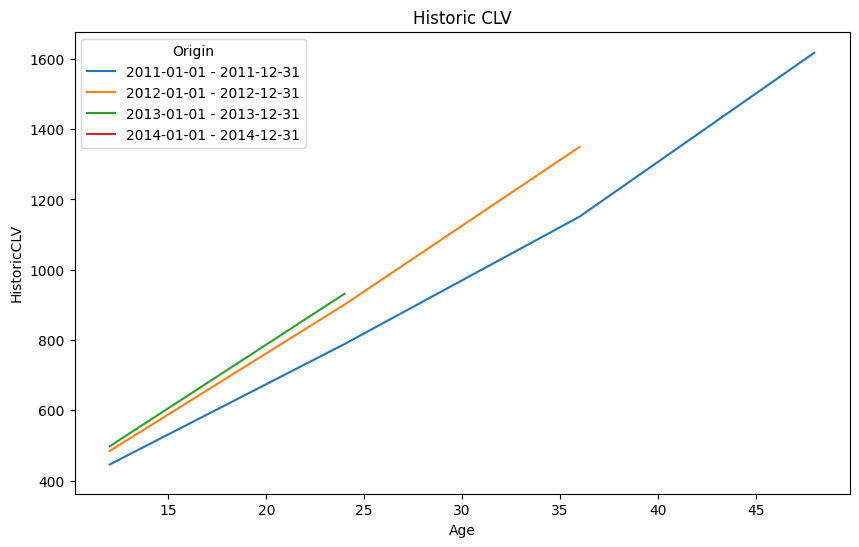

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.lineplot(x = hist_long['Age'],
             y = hist_long['HistoricCLV'],
             hue = hist_long['Origin'])

plt.title('Historic CLV')
plt.xlabel('Age')
plt.ylabel('HistoricCLV')
plt.show()

In [ ]:
# Match the Age columns (so both tables align properly)
HistoricCLV_table = HistoricCLV_table[NewCustomers_table.columns]

HistoricCLV_table.columns, NewCustomers_table.columns

(Index([12, 24, 36, 48], dtype='object', name='AgeRange'),
 Index([12, 24, 36, 48], dtype='object'))

In [ ]:
# Volume-weighted average:
# (sum over cohorts of (CLV * Customers)) / (sum over cohorts of Customers)

weighted_sum = (HistoricCLV_table * NewCustomers_table).sum(axis=0)
total_customers = NewCustomers_table.sum(axis=0)

vw_clv = weighted_sum / total_customers
vw_clv

,0
AgeRange,
12,461.606061
24,814.534091
36,1041.183081
48,969.914141


In [ ]:
vw_clv_table = vw_clv.reset_index()
vw_clv_table.columns = ['Age', 'HistoricCLV']

vw_clv_table

,Age,HistoricCLV
0,12,461.606061
1,24,814.534091
2,36,1041.183081
3,48,969.914141


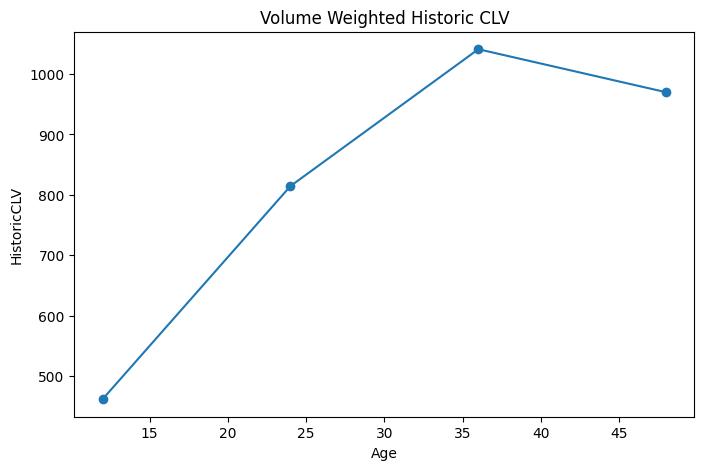

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(vw_clv_table['Age'], vw_clv_table['HistoricCLV'], marker='o')

plt.title('Volume Weighted Historic CLV')
plt.xlabel('Age')
plt.ylabel('HistoricCLV')
plt.show()

In [ ]:

# Q1) How much have customers acquired in 2011 spent to date?
# From the Historic CLV cohort plot, the 2011 cohort is observed up to Age = 48 months in your data.
# At Age = 48, the 2011 line is around ~1600 on the y-axis, meaning:
# Customers acquired in 2011 have spent approximately 1600 (currency units) per customer cumulatively to date
# (to the maximum age you can observe for that cohort in this dataset).

# Q2) Similar or different patterns? Implication?
# The cohorts show broadly similar patterns: spending increases with customer age (12 -> 24 -> 36 -> 48).
# However, the newer cohorts (2012/2013/2014) start slightly higher at early ages (12–24 months),
# while 2011 becomes highest at later ages mainly because it has more follow-up time (it reaches 36–48 months).